# Linear Regression on Housing Dataset

## Objective

The objective of this notebook is to build a machine learning pipeline using Linear Regression to predict housing prices.

Throughout this notebook we will cover:

- Loading the dataset
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Analysis
- Data Visualization
- Preprocessing
- Bias-Variance Tradeoff
- Model Training
- Model Evaluation
- Residual Analysis

This notebook demonstrates a complete supervised machine learning workflow.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [2]:
column_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    "housing.csv",
    sep=r"\s+",
    header=None,
    names=column_names
)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 506
Columns: 14


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [6]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
target = "MEDV"

print(df[target].describe())

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


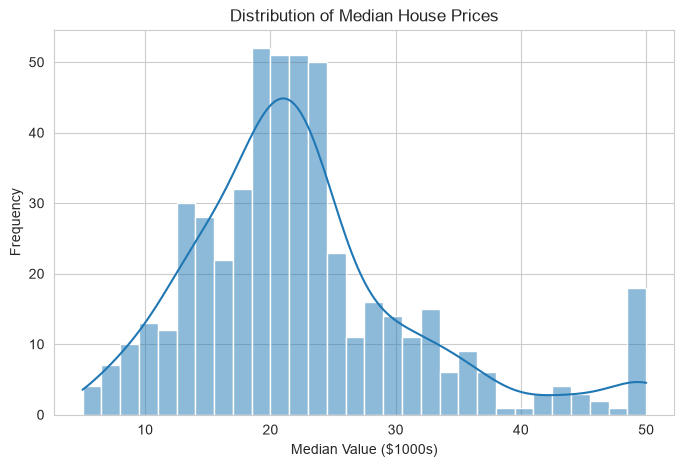

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["MEDV"], bins=30, kde=True)

plt.title("Distribution of Median House Prices")
plt.xlabel("Median Value ($1000s)")
plt.ylabel("Frequency")

plt.show()

The histogram shows that the target variable (MEDV) is not normally distributed. Most houses have median values between 15,000 and 30,000, with the highest concentration around 20,000–22,000. The distribution is positively skewed, indicating a small number of high-priced houses. A noticeable spike at 50 suggests that house prices were capped at $50,000 in the original dataset.

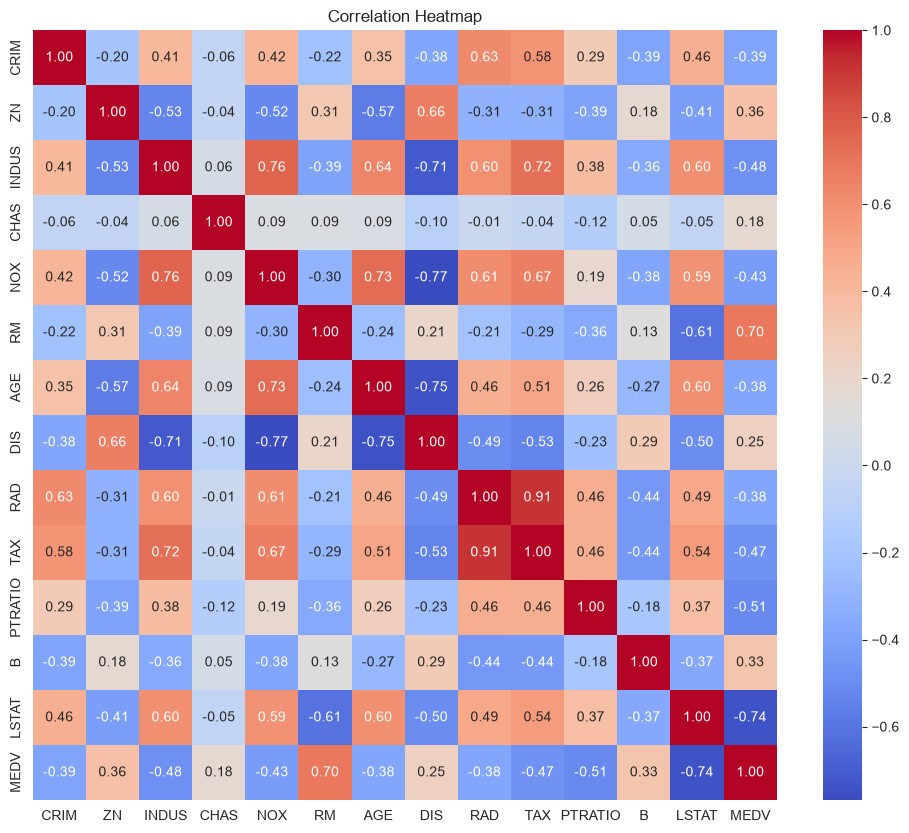

In [10]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
corr = df.corr()["MEDV"].sort_values(ascending=False)

corr


MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

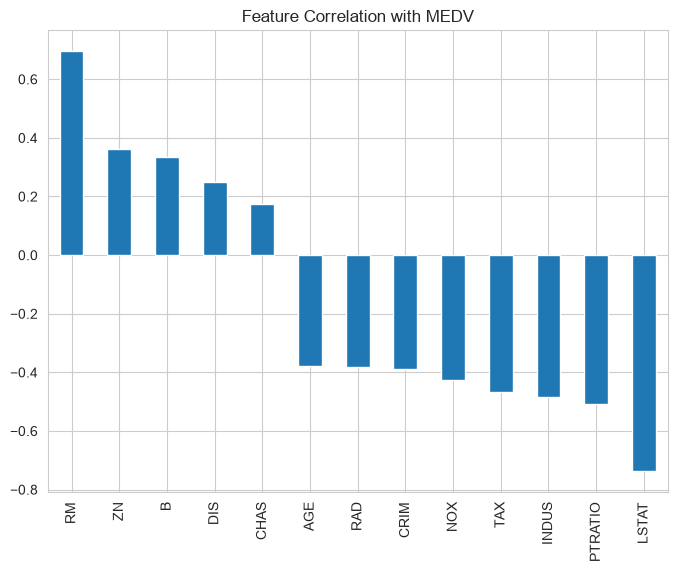

In [12]:
plt.figure(figsize=(8,6))

corr.drop("MEDV").plot(kind="bar")

plt.title("Feature Correlation with MEDV")

plt.show()

In [13]:
X = df.drop("MEDV", axis=1)

y = df["MEDV"]


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.97, 0.7 , 0.28,...,-1.98, 1.13,-3.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[49.49,24.72,22.79,..., 8.57, 8.35, 5. ]"


In [17]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,CRIM,-0.971494
1,ZN,0.701556
2,INDUS,0.276752
3,CHAS,0.706532
4,NOX,-1.991430
5,RM,3.115718
6,AGE,-0.177060
7,DIS,-3.045771
8,RAD,2.282785
9,TAX,-1.792605


In [18]:
coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
5,RM,3.115718
8,RAD,2.282785
11,B,1.126499
3,CHAS,0.706532
1,ZN,0.701556
2,INDUS,0.276752
6,AGE,-0.177060
0,CRIM,-0.971494
9,TAX,-1.792605
10,PTRATIO,-1.979954


In [19]:
y_pred = model.predict(X_test)

In [20]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880
76,20.0,23.254429
316,17.8,17.662538
140,14.0,14.341190
471,19.6,23.013207
500,16.8,20.632456


In [21]:
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.2f}")

MAE: 3.19


In [22]:
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:.2f}")

MSE: 24.29


In [23]:
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

RMSE: 4.93


In [24]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.3f}")

R² Score: 0.669


In [25]:
print("Model Evaluation")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

Model Evaluation
------------------------------
MAE  : 3.19
MSE  : 24.29
RMSE : 4.93
R²   : 0.669


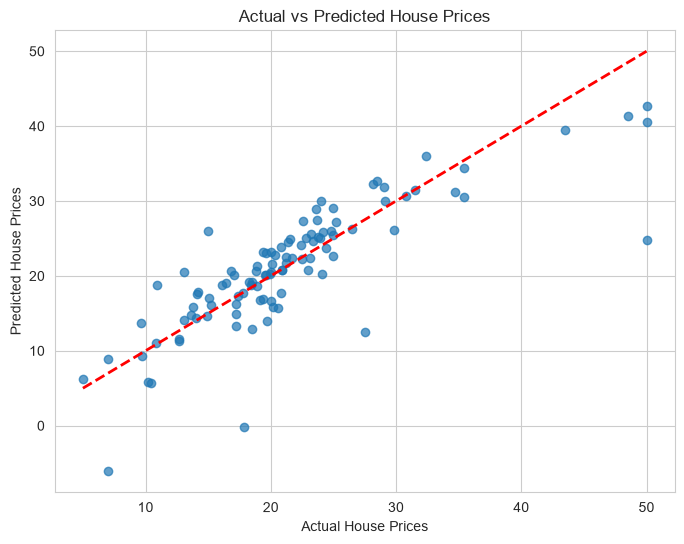

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Interpretation

The scatter plot compares the actual house prices with the predicted values.

- The red dashed line represents perfect predictions.
- Points closer to the line indicate more accurate predictions.
- The spread around the line represents prediction errors.

The model generally follows the overall trend but exhibits larger errors for some observations, suggesting that Linear Regression cannot capture all the complexity of the dataset.

In [27]:
residuals = y_test - y_pred

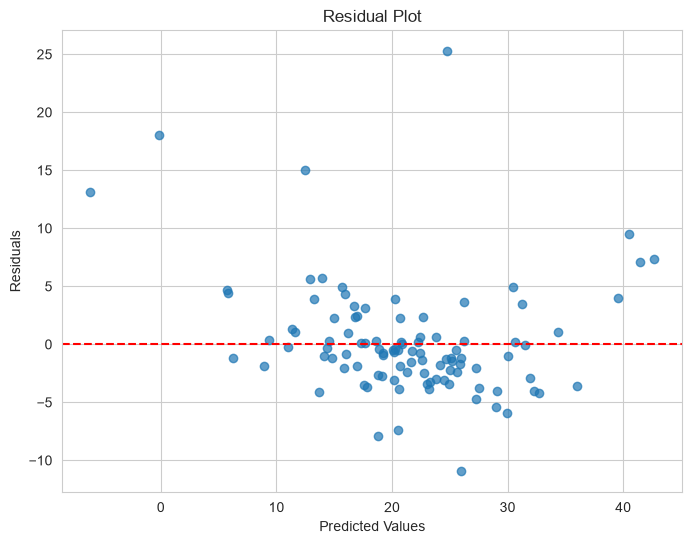

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

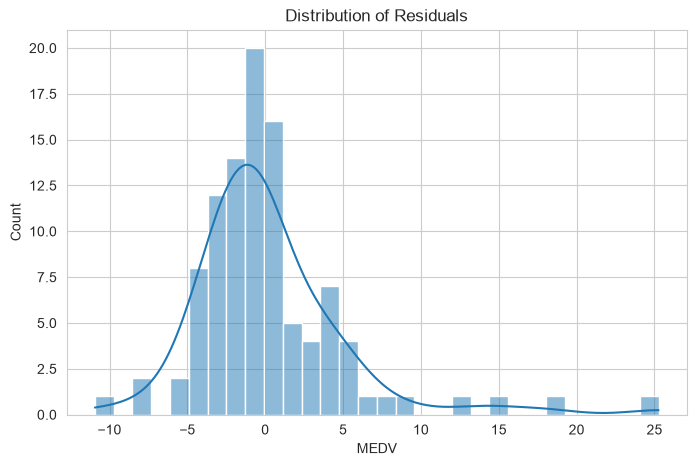

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals")

plt.show()

# Conclusion

In this notebook, a complete machine learning workflow was implemented using the Boston Housing dataset.

The following steps were performed:

- Loaded and explored the dataset
- Conducted Exploratory Data Analysis (EDA)
- Visualized feature distributions and correlations
- Preprocessed the data by scaling the features
- Split the dataset into training and testing sets
- Trained a Linear Regression model
- Evaluated the model using MAE, MSE, RMSE, and R² score
- Performed feature selection using Recursive Feature Elimination (RFE)
- Analyzed prediction errors using residual plots
- Interpreted the learned feature coefficients

### Model Performance

- **MAE:** 3.19
- **MSE:** 24.29
- **RMSE:** 4.93
- **R² Score:** 0.669

The model explained approximately **66.9%** of the variance in house prices, indicating a reasonable fit for a baseline Linear Regression model.

Although Recursive Feature Elimination (RFE) reduced the number of features, it resulted in a slightly lower R² score (0.659). Therefore, the model using all available features was retained as the final model.

Overall, this notebook demonstrates an end-to-end regression workflow, including data exploration, preprocessing, model training, evaluation, and interpretation.

## Future Improvements

Possible ways to improve model performance include:

- Feature engineering
- Polynomial Regression
- Ridge Regression
- Lasso Regression
- Elastic Net
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting (XGBoost, LightGBM)
- Hyperparameter tuning using GridSearchCV
- Cross-validation for more robust evaluation